**Finite Differences with Neural Surrogate versus Symbolic Regression**

*Mini-project by Hugo Robijns inspired by the work of Miles Cranmer and Liz Tan (PySR/SymTorch), and the principles of PhysicsX (Neural Surrogates/LPMs as a way of transforming classical numerical engineering processes).*

PhysicsX seeks to revolutionise engineering through the use of Large Physics Models, foundational engineering models trained on huge amounts of simulation and real-world data which can be used to provide inference *many orders of magnitudes faster* than equivalent numerical processes (FEM etc.). This allows real-time simulation and more thorough exploration of the design space.

Alongside this huge speed-up advantage:
- this approach is flexible (e.g. to different geometries/boundary conditions) instead of having to carry out a completely new numerical analysis each time (big cost advantage, only need to train these models once, although this training is large and expensive).
- functions much better in high dimensional work.

Some caveats/downsides/warning points are:
- this approach is strongly tied to its training data and these LPMs could therefore be biased (they're not inherently grounded to the maths in the way a numerical PDE solver is).
- large costs involved with improving/retraining this model if this is a huge computational job each time.
- although generalisation should be good, if it's far outside its training data scope, it might struggle where a numerical method will still be able to proceed (important for chaotic and non-linear systems).
- the models are black boxes, and therefore far less interpretable.

This notebook explores the final point, using recent work from the group where I'm carrying out my Master's project (https://astroautomata.com/), symbolic distillation of neural networks, and applying it to a neural surrogate to shed light on what is actually being 'learnt'. The proof-of-concept is the simple **Saint-Venant torsion problem* (Poisson's equation on a 2D disk).

To read more about the symbolic regression side:

_PySR_: https://ai.damtp.cam.ac.uk/pysr/v1.5.9/

_SymTorch_: https://symtorch.readthedocs.io/en/latest/
___

Run (once, from the repo root):
```
python3 -m venv venv && source venv/bin/activate
pip install .
```

In [1]:
# import relevant libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pysr
import symtorch


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/hugo/Documents/NumericalNeuralSurrogate/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/hugo/Documents/NumericalNeuralSurrogate/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/hugo/Documents/NumericalNeuralSurrogate/venv/lib/python3.12/site-packages/i

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


___
**Data Generation: numerical solution of Saint-Venant's problem.**

A circular shaft of unit radius is twisted about its axis. Saint-Venant's semi-inverse method introduces the **Prandtl stress function** $\varphi$, which satisfies Poisson's equation over the cross-section:

$$\nabla^2 \varphi = -2G\Theta \quad \text{on } x^2+y^2 < 1, \qquad \varphi = 0 \text{ on } x^2+y^2 = 1$$

where $G$ is the shear modulus and $\Theta$ is the angle of twist per unit length. In dimensionless units ($G = \Theta = 1$) this becomes $\nabla^2 \varphi = -2$, with exact solution:

$$\varphi(x,y) = \frac{1 - x^2 - y^2}{2}$$

and shear stresses $\tau_{xz} = \partial\varphi/\partial y = -y$, $\tau_{yz} = -\partial\varphi/\partial x = x$; a pure rotational stress field, as expected.

This is a simple proof-of-concept example, but we could change/increase the complexity of a) the geometry/mesh (and use e.g. FEM to solve) and b) the PDE.

In [2]:
def solve_poisson_disk(n=64, iters=5000, f_val=-2.0):

    h = 2.0 / (n - 1)                  
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    Xg, Yg  = np.meshgrid(x, y, indexing='ij')
    R2 = Xg**2 + Yg**2
    interior = R2 < 1.0              

    f = np.full((n, n), f_val)
    u = np.zeros((n, n))

    for _ in range(iters):
        u_new = np.zeros_like(u)
        u_new[1:-1, 1:-1] = 0.25 * (
            u[2:,  1:-1] + u[:-2, 1:-1] +
            u[1:-1, 2:]  + u[1:-1, :-2] -
            h**2 * f[1:-1, 1:-1]
        )
        u_new[~interior] = 0.0 # b.c.s 
        u = u_new

    return Xg, Yg, u, interior

Training points: (3096, 2),  Targets: (3096, 1)
Max FD error vs. exact solution: 0.01551  (O(h²) expected)


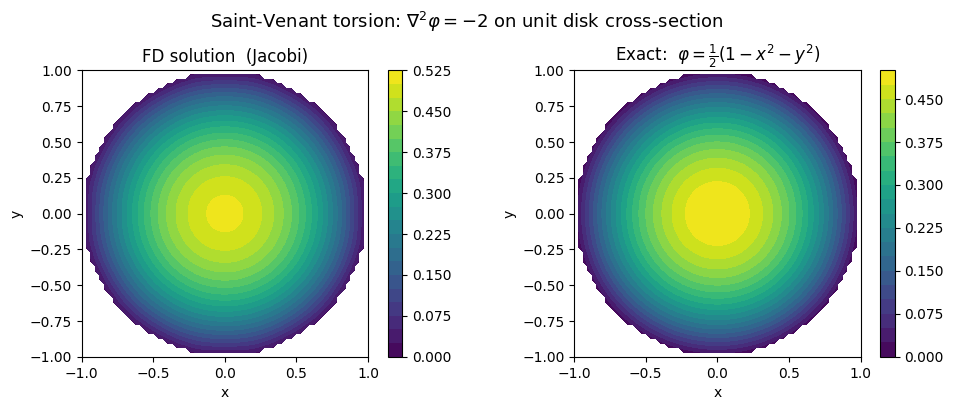

In [3]:
def generate_dataset(n=64, iters=5000):
    Xg, Yg, u_fd, interior = solve_poisson_disk(n=n, iters=iters)

    x_pts = Xg[interior]
    y_pts = Yg[interior]
    u_pts = u_fd[interior]

    X = np.stack([x_pts, y_pts], axis=1)
    Y = u_pts[:, None]                     
    return X, Y, Xg, Yg, u_fd, interior

X, Y, Xg, Yg, u_fd, interior = generate_dataset()
print(f"Training points: {X.shape},  Targets: {Y.shape}")

# validate FD solution against the known exact solution
u_exact   = np.where(interior, (1 - Xg**2 - Yg**2) / 2, np.nan)
u_fd_plot = np.where(interior, u_fd, np.nan)
max_err   = np.nanmax(np.abs(u_fd_plot - u_exact))
print(f"Max FD error vs. exact solution: {max_err:.5f}  (O(h²) expected)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(
    axes,
    [u_fd_plot, u_exact],
    ['FD solution  (Jacobi)', r'Exact:  $\varphi = \frac{1}{2}(1 - x^2 - y^2)$']
):
    cf = ax.contourf(Xg, Yg, data, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax)
    ax.set_title(title); ax.set_aspect('equal')
    ax.set_xlabel('x');  ax.set_ylabel('y')

plt.suptitle(r'Saint-Venant torsion: $\nabla^2\varphi = -2$ on unit disk cross-section', fontsize=13)
plt.tight_layout(); plt.show()

___
**Neural Surrogate: training an MLP on the simulated data.**

We use the simulated data to train a simple MLP. This MLP, once trained, will be able to provide near real-time inference of the same problem (the advantage of which becomes clear in larger and more complex scenarios).

Epoch    0,  MSE loss: 0.0787425
Epoch  100,  MSE loss: 0.0106426
Epoch  200,  MSE loss: 0.0012128
Epoch  300,  MSE loss: 0.0004345
Epoch  400,  MSE loss: 0.0003574
Epoch  500,  MSE loss: 0.0002985


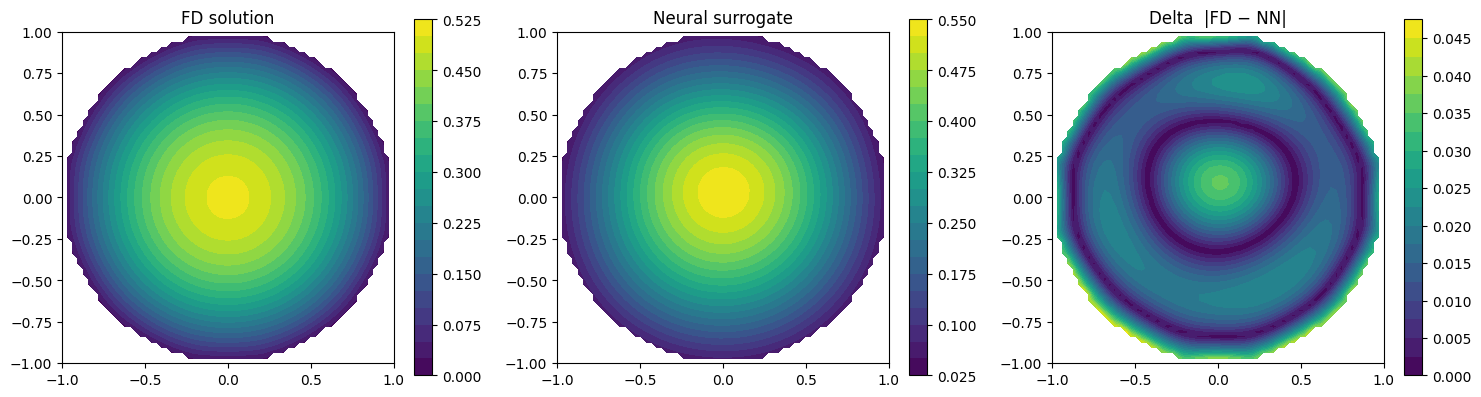

In [4]:
X_t = torch.tensor(X, dtype=torch.float32)
Y_t = torch.tensor(Y, dtype=torch.float32)

# two inputs (x, y); f is fixed so the surrogate only needs position
model = nn.Sequential(
    nn.Linear(2, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(501):
    pred = model(X_t)
    loss = ((pred - Y_t)**2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d},  MSE loss: {loss.item():.7f}")

# juliacall (loaded by pysr) breaks torch's numpy bridge, so convert via tolist()
with torch.no_grad():
    u_nn_pts = np.array(model(X_t).tolist()).flatten()

u_nn = np.full(Xg.shape, np.nan)
u_nn[interior] = u_nn_pts

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    (u_fd_plot, 'FD solution'),
    (u_nn, 'Neural surrogate'),
    (np.where(interior, np.abs(u_fd_plot - u_nn), np.nan), 'Delta  |FD − NN|'),
]
for ax, (data, title) in zip(axes, panels):
    cf = ax.contourf(Xg, Yg, data, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax)
    ax.set_title(title); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

___
**Interpreting the Neural Surrogate: symbolic distillation with SymTorch.**

We now apply PySR-based symbolic regression to the trained neural network (not the raw data), distilling the black box into a human-readable formula.

If the surrogate has genuinely learned the Saint-Venant torsion physics, SymTorch should recover the Prandtl stress function:

$$\hat{\varphi}(x_1, x_2) \approx \frac{1}{2}(1 - x_1^2 - x_2^2)$$

without ever being told the governing PDE. This would confirm that the surrogate has internalised the correct mechanics — not just memorised the training data.

In [7]:
def model_fn(x_numpy):
    x = torch.tensor(x_numpy, dtype=torch.float32)
    with torch.no_grad():
        return np.array(model(x).tolist())

sym_model = symtorch.SymbolicModel(model_fn)

sr_params = {
    'niterations': 500,
    'binary_operators': ['+', '-', '*'],
    'unary_operators': None,
    'maxsize': 15,
    'populations': 20,
}

result = sym_model.distill(X, sr_params=sr_params)
print(result)

/Users/hugo/Documents/NumericalNeuralSurrogate/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.500e+04
Progress: 87 / 10000 total iterations (0.870%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.977e-02  0.000e+00  y = 0.26037
7           1.319e-02  6.738e-02  y = (x₀ * (x₀ * -0.32741)) + 0.34166
9           1.300e-02  7.546e-03  y = 0.30182 - ((x₀ * x₀) * (x₁ * x₁))
11          1.171e-02  5.187e-02  y = 0.3293 - (((x₀ * 1.6633) * (x₁ * x₁)) * x₀)
13          1.171e-02  2.712e-05  y = 0.3293 - (((-0.0038591 - x₀) * (x₀ * (x₁ * x₁))) * -1....
                                      6634)
15          9.446e-03  1.076e-01  y = ((x₁ * (x₁ * -0.24063)) + 0.36156) - (((x₀ * x₁) * x₁)...
                                       * x₀)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.977e-02  0.000e+00  y = 0.26037
5           1.977e-02  1.639e-07  y = (x₁ * -0.00024407) + 0.26037
7           1.319e-02  2.021e-01  y = ((x₀ * x₀) * -0.32742) + 0.34166
9           1.300e-02  7.546e-03  y = 0.30182 - ((x₀ * x₀) * (x₁ * x₁))
11          2.885e-04  1.904e+00  y = (((x₀ * x₀) + (x₁ * x₁)) * -0.48679) + 0.5021
13          2.884e-04  1.935e-04  y = (((x₁ * -0.48596) * x₁) + 0.5021) + ((x₀ * x₀) * -0.48...
                                      762)
15          2.884e-04  2.351e-05  y = ((x₁ * ((x₁ * -0.48597) + -0.00023354)) + 0.5021) + ((...
                                      x₀ * x₀) * -0.48762)
───────────────────────────────────────────────────────────────────────────────────────────────────
{0: PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.0

Highest score is complexity 11:
$$\hat{\varphi}(x_1, x_2) = (x_1^2 + x_2^2) \times -0.49 + 0.5 \approx \frac{1}{2}(1 - x_1^2 - x_2^2)$$
This is obviously a very simple example, but proof of concept!

In [8]:
import time

# FD solver: one full solve on the same grid
t0 = time.perf_counter()
solve_poisson_disk(n=64, iters=5000)
t_fd = time.perf_counter() - t0

# Neural surrogate: forward pass over the same interior points
X_query = torch.tensor(X, dtype=torch.float32)
t0 = time.perf_counter()
with torch.no_grad():
    _ = np.array(model(X_query).tolist())
t_nn = time.perf_counter() - t0

print(f"FD solver (5000 Jacobi iterations): {t_fd * 1e3:8.1f} ms")
print(f"Neural surrogate (forward pass): {t_nn * 1e3:8.2f} ms")
print(f"Speedup: {t_fd / t_nn:8.0f}×")

FD solver (5000 Jacobi iterations):    213.5 ms
Neural surrogate (forward pass):    11.25 ms
Speedup:       19×


Also a nifty speed-up... not bad! 